# Phase 2: Complete Preprocessing Analysis with Visualizations

## Overview
This notebook provides a **complete step-by-step analysis** of the Phase 2 preprocessing pipeline with:
- Visual comparisons at each preprocessing step
- Signal quality metrics before and after each transformation
- Statistical analysis of the preprocessing effects
- Interactive visualizations showing what changes at each step

**Goal:** Understand exactly what happens to the EEG signals during preprocessing.

**Approach:** We'll take one subject's raw data and process it step-by-step, visualizing the effects of each transformation.

## Setup

In [43]:
# Find project root and setup paths
import os
import sys
from pathlib import Path

# Find project root
current_dir = Path.cwd()
project_root = None

for potential_root in [current_dir, current_dir.parent, current_dir.parent.parent]:
    if (potential_root / 'src').exists() and (potential_root / 'data').exists():
        project_root = potential_root
        break

if project_root:
    os.chdir(project_root)
    sys.path.insert(0, str(project_root))
    print(f"Working directory: {os.getcwd()}")
else:
    print("Warning: Could not determine project root")
    print(f"Current directory: {current_dir}")

Working directory: d:\EEG2Img-Benchmark-Study


In [44]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from scipy import signal, stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import MNE for EEG processing
import mne
from mne.preprocessing import ICA

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10

print("All libraries imported successfully")
print(f"MNE version: {mne.__version__}")
print(f"NumPy version: {np.__version__}")

All libraries imported successfully
MNE version: 1.12.0
NumPy version: 2.2.5


## Part 1: Load Raw Data

First, let's load the **raw, unprocessed** EEG data from the BCI Competition IV-2a dataset.

In [45]:
# Load raw data for one subject (A01T)
raw_data_path = Path('data/raw/bci_iv_2a')
subject_id = 1
session = 'T'

# Construct filename
filename = raw_data_path / f'A0{subject_id}{session}.gdf'

if filename.exists():
    print(f"Loading raw data: {filename}")
    
    # Load with MNE
    raw = mne.io.read_raw_gdf(filename, preload=True, verbose=False)
    
    print(f"\nRaw Data Information:")
    print(f"  Sampling rate: {raw.info['sfreq']} Hz")
    print(f"  Number of channels: {len(raw.ch_names)}")
    print(f"  Channel names: {raw.ch_names[:10]}... (showing first 10)")
    print(f"  Duration: {raw.times[-1]:.2f} seconds")
    print(f"  Number of samples: {len(raw.times):,}")
    
    # Get events
    events = mne.events_from_annotations(raw, verbose=False)[0]
    print(f"\n  Number of events: {len(events)}")
else:
    print(f"ERROR: Raw data file not found at {filename}")
    print("Please ensure you've downloaded the BCI Competition IV-2a dataset.")

Loading raw data: data\raw\bci_iv_2a\A01T.gdf

Raw Data Information:
  Sampling rate: 250.0 Hz
  Number of channels: 25
  Channel names: ['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz']... (showing first 10)
  Duration: 2690.11 seconds
  Number of samples: 672,528

  Number of events: 603


### Visualize Raw Signal

Let's look at the raw EEG signal before any preprocessing:

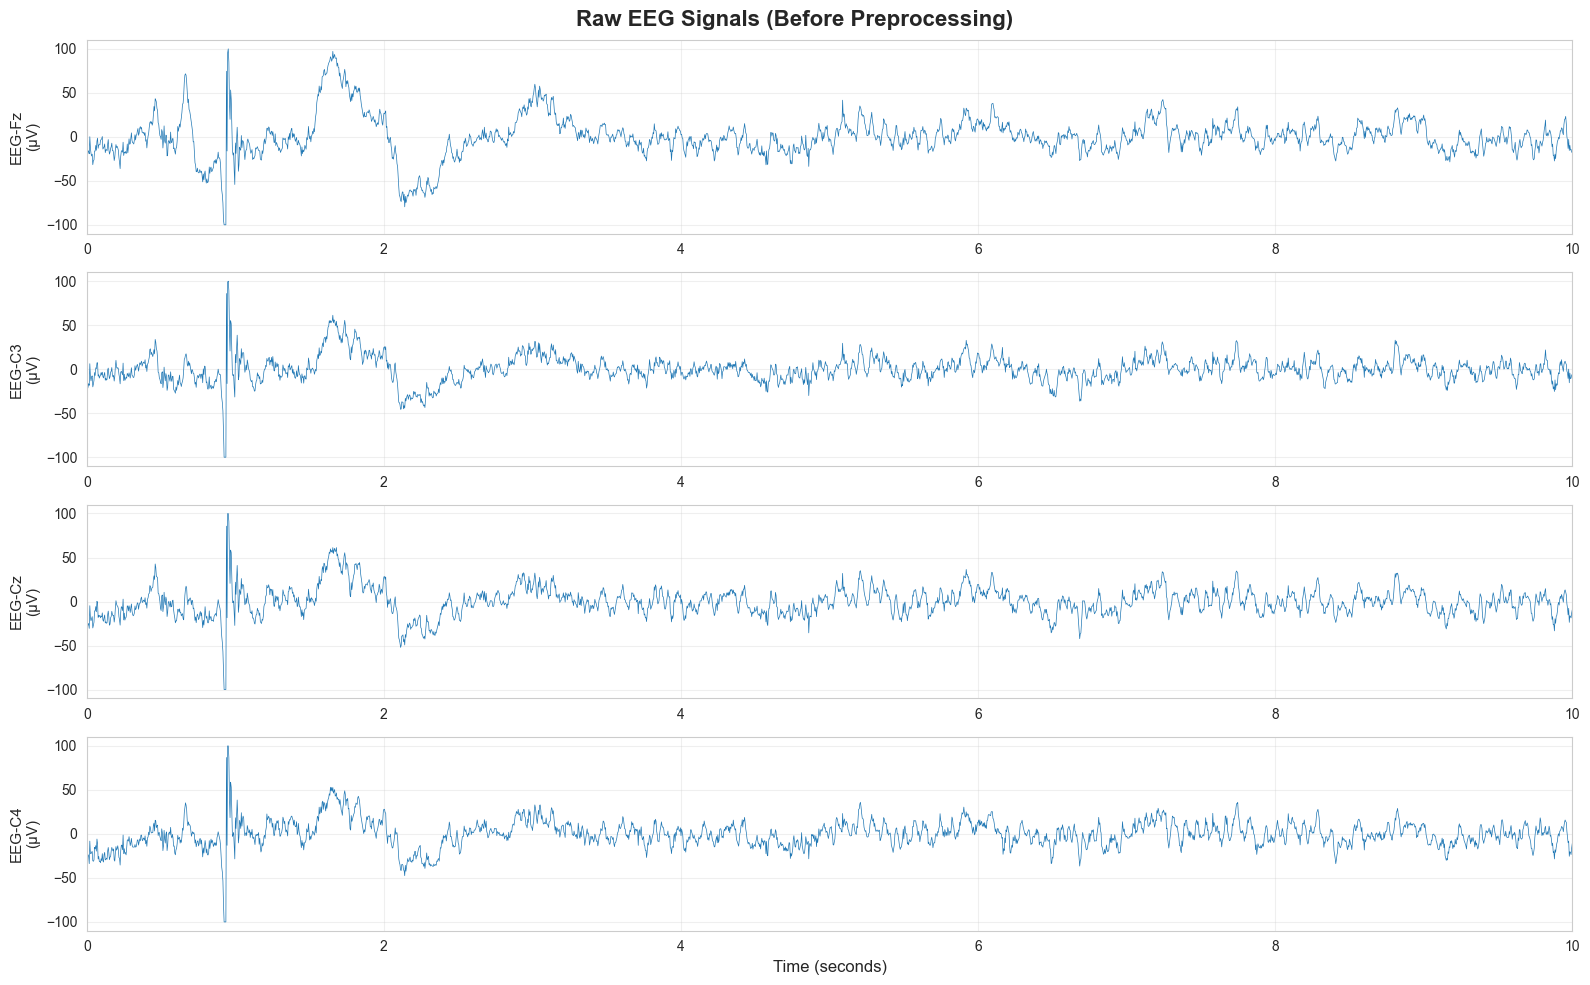

Plotted channels: ['EEG-Fz', 'EEG-C3', 'EEG-Cz', 'EEG-C4']
Notice: Raw signals contain artifacts, noise, and DC offset.


In [46]:
# Plot first 10 seconds of raw data from a few channels
fig, axes = plt.subplots(4, 1, figsize=(16, 10))
fig.suptitle('Raw EEG Signals (Before Preprocessing)', fontsize=16, fontweight='bold')

# Get available channels - handle different naming conventions
available_channels = raw.ch_names

# Try to find motor cortex channels with flexible naming
channels_to_plot = []
for target in ['Fz', 'C3', 'Cz', 'C4']:
    for ch in available_channels:
        if target in ch:
            channels_to_plot.append(ch)
            break

# If we couldn't find enough, just use first 4 EEG channels
if len(channels_to_plot) < 4:
    channels_to_plot = [ch for ch in available_channels if 'EEG' in ch][:4]

time_window = [0, 10]  # First 10 seconds

for idx, ch_name in enumerate(channels_to_plot):
    ch_idx = raw.ch_names.index(ch_name)
    data, times = raw[ch_idx, :]
    
    # Plot only first 10 seconds
    time_mask = times <= time_window[1]
    axes[idx].plot(times[time_mask], data[0, time_mask] * 1e6, linewidth=0.5)
    axes[idx].set_ylabel(f'{ch_name}\n(µV)', fontsize=11)
    axes[idx].set_xlim(time_window)
    axes[idx].grid(True, alpha=0.3)
        
axes[-1].set_xlabel('Time (seconds)', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Plotted channels: {channels_to_plot}")
print("Notice: Raw signals contain artifacts, noise, and DC offset.")

### Raw Signal Statistics

In [47]:
# Get EEG channels only (exclude EOG)
eeg_channels = [ch for ch in raw.ch_names if not ch.startswith('EOG')]
raw_eeg = raw.copy().pick_channels(eeg_channels)

# Calculate statistics
data = raw_eeg.get_data() * 1e6  # Convert to µV

stats_df = pd.DataFrame({
    'Channel': eeg_channels,
    'Mean (µV)': data.mean(axis=1),
    'Std (µV)': data.std(axis=1),
    'Min (µV)': data.min(axis=1),
    'Max (µV)': data.max(axis=1),
    'Peak-to-Peak (µV)': data.max(axis=1) - data.min(axis=1)
})

print("Raw Signal Statistics (EEG channels only):")
print("=" * 80)
print(stats_df.to_string(index=False))
print("\nOverall Statistics:")
print(f"  Mean amplitude: {data.mean():.2f} µV")
print(f"  Std amplitude: {data.std():.2f} µV")
print(f"  Max amplitude: {data.max():.2f} µV")
print(f"  Min amplitude: {data.min():.2f} µV")

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Raw Signal Statistics (EEG channels only):
Channel  Mean (µV)  Std (µV)  Min (µV)  Max (µV)  Peak-to-Peak (µV)
 EEG-Fz  -1.563889 57.195944   -1600.0 99.951172        1699.951172
  EEG-0  -1.558359 56.549849   -1600.0 99.951172        1699.951172
  EEG-1  -1.553830 56.671928   -1600.0 99.951172        1699.951172
  EEG-2  -1.557845 56.788522   -1600.0 99.951172        1699.951172
  EEG-3  -1.558328 56.696361   -1600.0 99.951172        1699.951172
  EEG-4  -1.551441 56.683691   -1600.0 99.951172        1699.951172
  EEG-5  -1.559587 56.049736   -1600.0 99.951172        1699.951172
 EEG-C3  -1.558024 56.262848   -1600.0 99.951172        1699.951172
  EEG-6  -1.565892 56.426868   -1600.0 99.951172        1699.951172
 EEG-Cz  -1.555390 56.596419   -1600.0 99.951172        1699.951172
  EEG-7  -1.559273 56.504358   -1600.0 99.951172        1699.951172
 EEG-C4  -1.557992 56.429909   -1600.0 99.951172        1699.

## Part 2: Frequency Filtering

**Step 1:** Apply band-pass filter (0.5-40 Hz) and notch filter (50 Hz)

In [48]:
# Create a copy for filtering
raw_filtered = raw_eeg.copy()

# Apply band-pass filter
print("Applying band-pass filter (0.5-40 Hz)...")
raw_filtered.filter(l_freq=0.5, h_freq=40.0, verbose=False)

# Apply notch filter (50 Hz - power line noise)
print("Applying notch filter (50 Hz)...")
raw_filtered.notch_filter(freqs=50, verbose=False)

print("Filtering complete!")

Applying band-pass filter (0.5-40 Hz)...
Applying notch filter (50 Hz)...
Filtering complete!


### Compare: Raw vs Filtered Signal

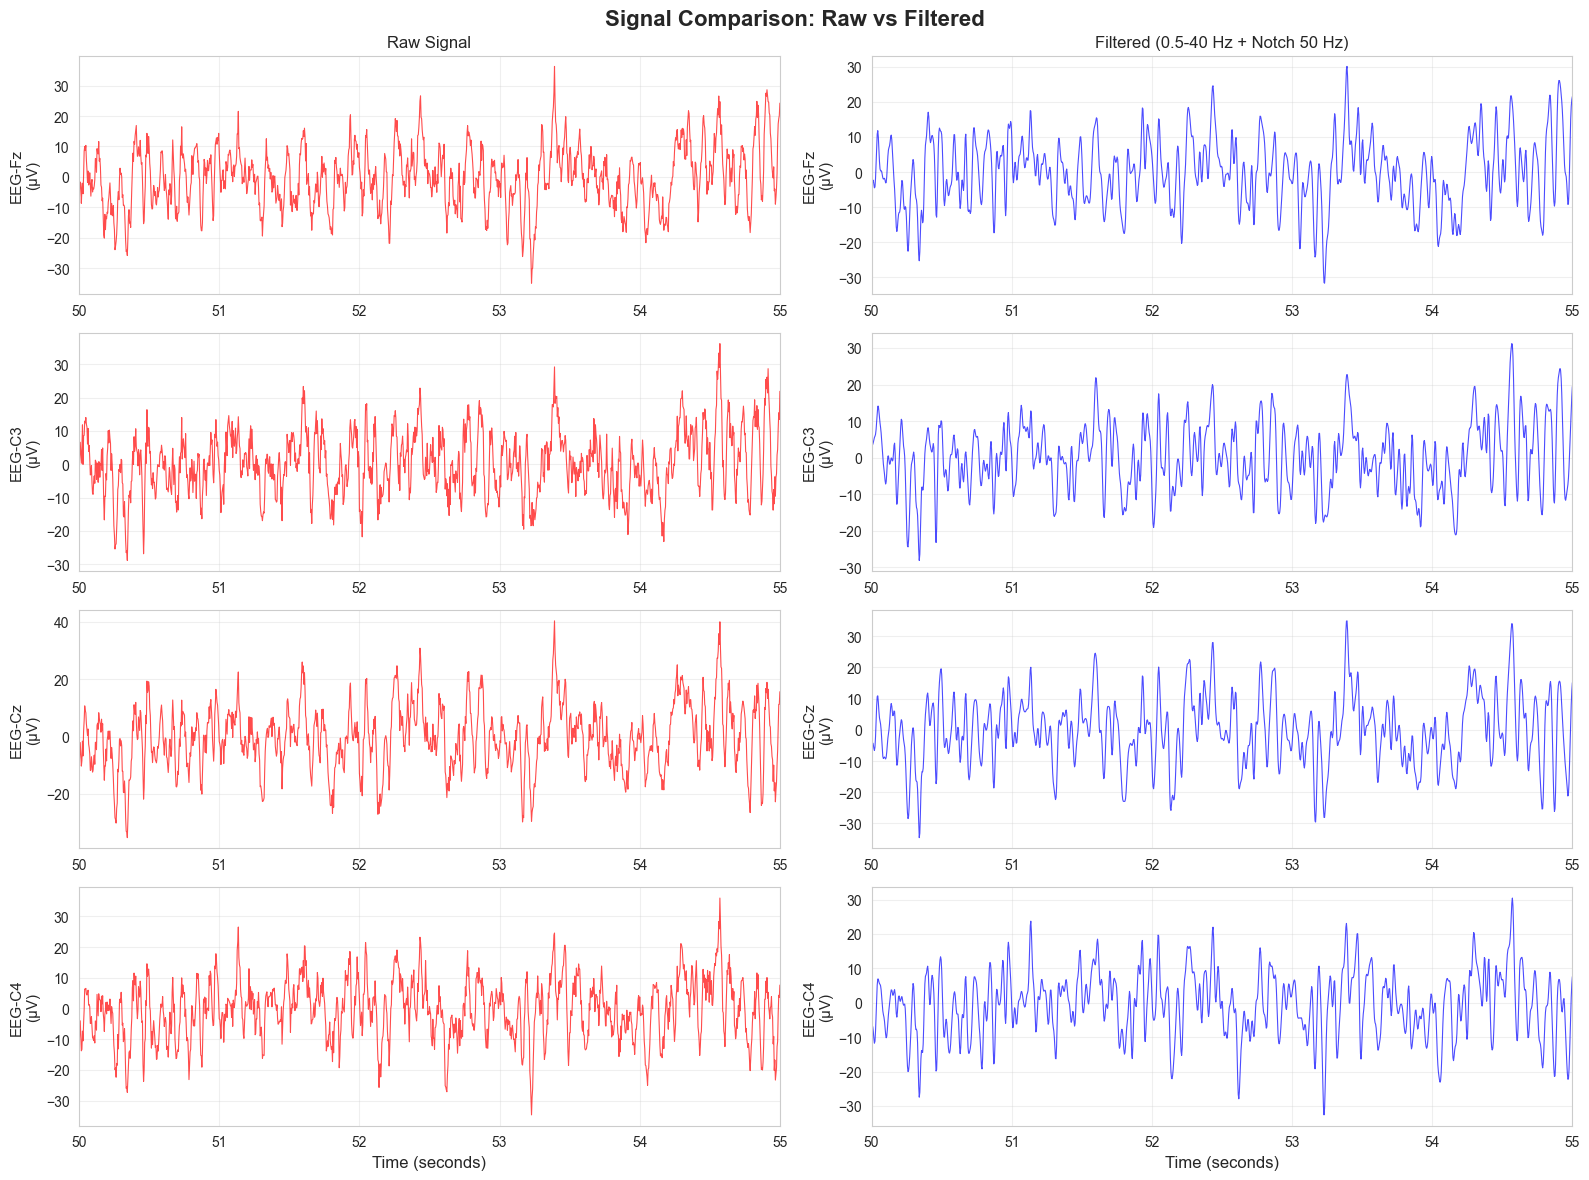

Notice: Filtered signal has reduced low-frequency drift and high-frequency noise.


In [49]:
# Plot comparison
fig, axes = plt.subplots(4, 2, figsize=(16, 12))
fig.suptitle('Signal Comparison: Raw vs Filtered', fontsize=16, fontweight='bold')

# Get available channels - handle different naming conventions
available_channels = raw_eeg.ch_names
channels_to_plot = []
for target in ['Fz', 'C3', 'Cz', 'C4']:
    for ch in available_channels:
        if target in ch:
            channels_to_plot.append(ch)
            break

# If we couldn't find enough, just use first 4 EEG channels
if len(channels_to_plot) < 4:
    channels_to_plot = [ch for ch in available_channels if 'EEG' in ch][:4]

time_window = [50, 55]  # 5-second window

for idx, ch_name in enumerate(channels_to_plot):
    ch_idx = raw_eeg.ch_names.index(ch_name)
    
    # Get raw data
    data_raw, times = raw_eeg[ch_idx, :]
    time_mask = (times >= time_window[0]) & (times <= time_window[1])
    
    # Get filtered data
    data_filt, _ = raw_filtered[ch_idx, :]
    
    # Plot raw
    axes[idx, 0].plot(times[time_mask], data_raw[0, time_mask] * 1e6, 
                     linewidth=0.8, color='red', alpha=0.7)
    axes[idx, 0].set_ylabel(f'{ch_name}\n(µV)', fontsize=11)
    axes[idx, 0].set_title('Raw Signal' if idx == 0 else '', fontsize=12)
    axes[idx, 0].grid(True, alpha=0.3)
    axes[idx, 0].set_xlim(time_window)
    
    # Plot filtered
    axes[idx, 1].plot(times[time_mask], data_filt[0, time_mask] * 1e6, 
                     linewidth=0.8, color='blue', alpha=0.7)
    axes[idx, 1].set_ylabel(f'{ch_name}\n(µV)', fontsize=11)
    axes[idx, 1].set_title('Filtered (0.5-40 Hz + Notch 50 Hz)' if idx == 0 else '', fontsize=12)
    axes[idx, 1].grid(True, alpha=0.3)
    axes[idx, 1].set_xlim(time_window)

axes[-1, 0].set_xlabel('Time (seconds)', fontsize=12)
axes[-1, 1].set_xlabel('Time (seconds)', fontsize=12)
plt.tight_layout()
plt.show()

print("Notice: Filtered signal has reduced low-frequency drift and high-frequency noise.")

### Power Spectral Density: Before vs After Filtering

Plotting PSD for channel: EEG-Cz
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().


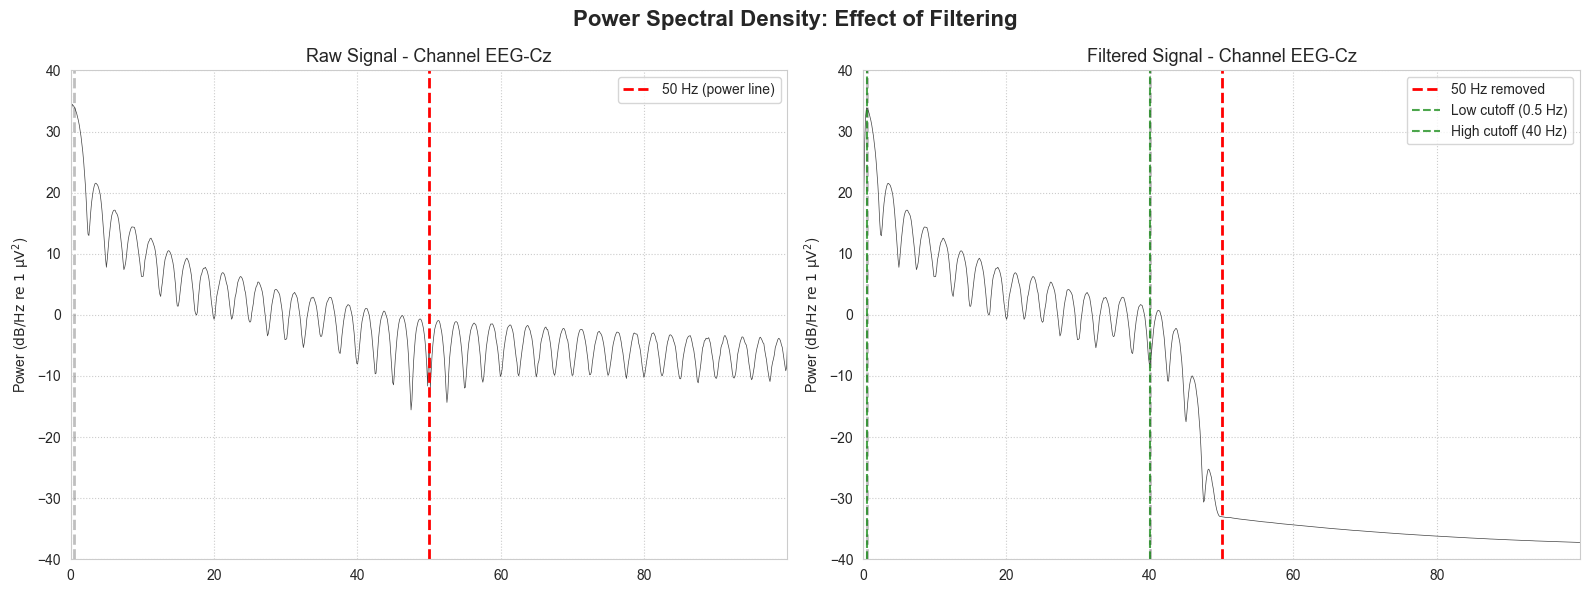

Notice: 
  - 50 Hz power line noise is removed (notch filter)
  - Low frequencies below 0.5 Hz are attenuated (removes DC drift)
  - High frequencies above 40 Hz are attenuated (removes muscle noise)


In [50]:
# Compute PSD for raw and filtered signals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Power Spectral Density: Effect of Filtering', fontsize=16, fontweight='bold')

# Find a good channel for PSD analysis
available_channels = raw_eeg.ch_names
ch_name = None
for target in ['Cz', 'C3', 'C4']:
    for ch in available_channels:
        if target in ch:
            ch_name = ch
            break
    if ch_name:
        break

if ch_name is None:
    ch_name = [ch for ch in available_channels if 'EEG' in ch][0]

print(f"Plotting PSD for channel: {ch_name}")

# Raw PSD
raw_eeg.plot_psd(picks=[ch_name], fmax=100, ax=axes[0], show=False, verbose=False)
axes[0].set_title(f'Raw Signal - Channel {ch_name}', fontsize=13)
axes[0].set_ylim([-40, 40])
axes[0].axvline(50, color='red', linestyle='--', linewidth=2, label='50 Hz (power line)')
axes[0].legend()

# Filtered PSD
raw_filtered.plot_psd(picks=[ch_name], fmax=100, ax=axes[1], show=False, verbose=False)
axes[1].set_title(f'Filtered Signal - Channel {ch_name}', fontsize=13)
axes[1].set_ylim([-40, 40])
axes[1].axvline(50, color='red', linestyle='--', linewidth=2, label='50 Hz removed')
axes[1].axvline(0.5, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Low cutoff (0.5 Hz)')
axes[1].axvline(40, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='High cutoff (40 Hz)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Notice: ")
print("  - 50 Hz power line noise is removed (notch filter)")
print("  - Low frequencies below 0.5 Hz are attenuated (removes DC drift)")
print("  - High frequencies above 40 Hz are attenuated (removes muscle noise)")

## Part 3: ICA Artifact Removal

**Step 2:** Use Independent Component Analysis (ICA) to remove eye blinks and muscle artifacts

In [51]:
# Apply ICA
print("Fitting ICA (this may take 1-2 minutes)...")

# Create ICA object
ica = ICA(n_components=20, random_state=42, max_iter=500, verbose=False)

# Fit ICA on filtered data
ica.fit(raw_filtered, verbose=False)

print(f"ICA fitted with {ica.n_components_} components")
print(f"\nExplained variance: {ica.pca_explained_variance_[:10].sum():.2f}% (first 10 components)")

Fitting ICA (this may take 1-2 minutes)...
ICA fitted with 20 components

Explained variance: 22.00% (first 10 components)


### Visualize ICA Components

Plotting ICA component time series...


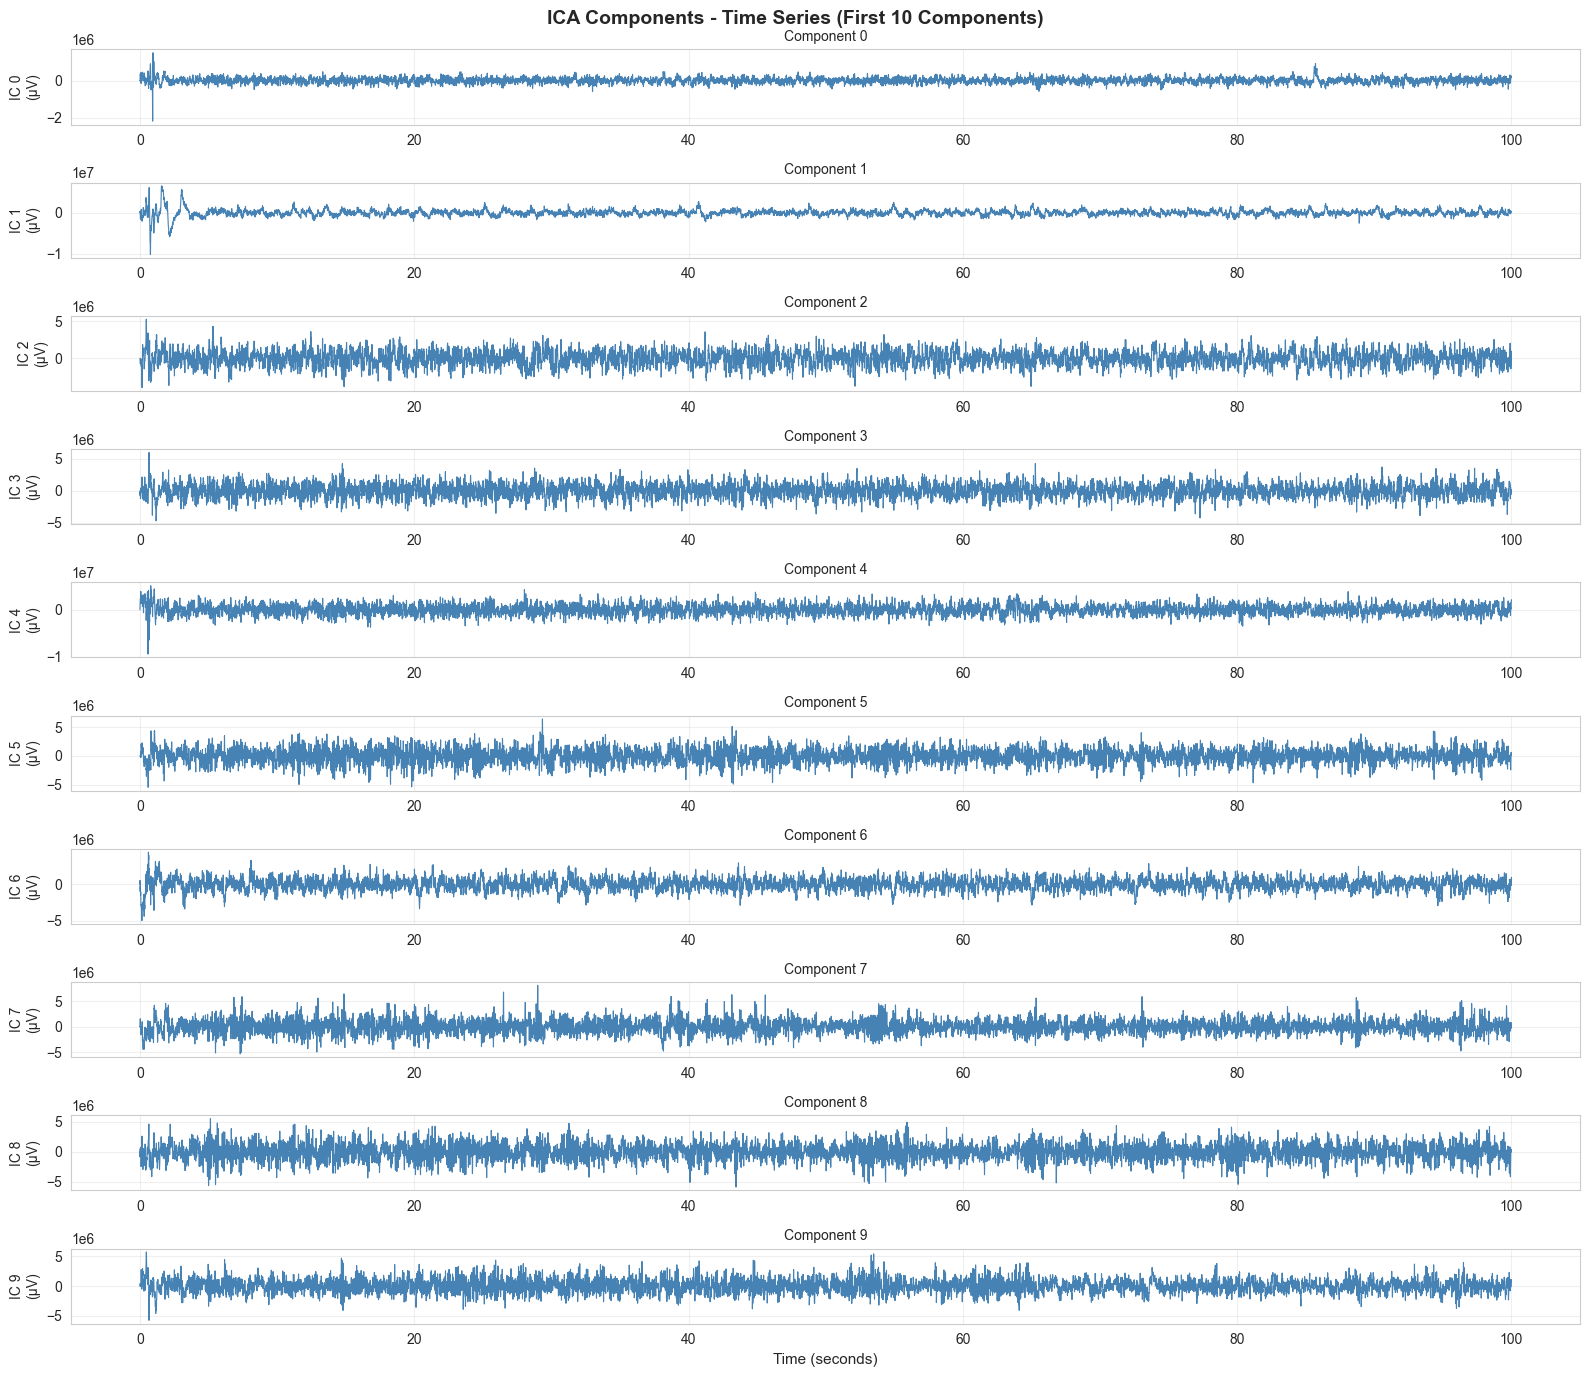


ICA Components Visualization:
  Total components: 10 shown (out of 20 fitted)
  Excluded (artifacts): []

Red backgrounds indicate components that were marked as artifacts (eye blinks, muscle noise)

Look for:
  - High-amplitude, repetitive spikes = eye blink artifact
  - Muscle noise = rapid, jagged components
  - Brain activity = smoother, more structured patterns


In [52]:
# Visualize ICA components as time series
print("Plotting ICA component time series...")

# Create figure with time series of first 10 ICA components
fig, axes = plt.subplots(10, 1, figsize=(16, 14))
fig.suptitle('ICA Components - Time Series (First 10 Components)', fontsize=14, fontweight='bold')

# Get ICA sources
ica_sources = ica.get_sources(raw_filtered)
source_data = ica_sources.get_data() * 1e6  # Convert to µV

# Plot first 100 seconds of each component
time_window = [0, 100]
time_mask = (ica_sources.times >= time_window[0]) & (ica_sources.times <= time_window[1])

for comp_idx in range(10):
    axes[comp_idx].plot(ica_sources.times[time_mask], source_data[comp_idx, time_mask], 
                       linewidth=0.8, color='steelblue')
    axes[comp_idx].set_ylabel(f'IC {comp_idx}\n(µV)', fontsize=10)
    axes[comp_idx].grid(True, alpha=0.3)
    
    # Highlight excluded components
    if comp_idx in ica.exclude:
        axes[comp_idx].set_facecolor('#ffcccc')  # Light red
        axes[comp_idx].set_title(f'Component {comp_idx} (EXCLUDED - artifact)', fontsize=10, fontweight='bold')
    else:
        axes[comp_idx].set_title(f'Component {comp_idx}', fontsize=10)

axes[-1].set_xlabel('Time (seconds)', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nICA Components Visualization:")
print(f"  Total components: 10 shown (out of {ica.n_components_} fitted)")
print(f"  Excluded (artifacts): {ica.exclude}")
print(f"\nRed backgrounds indicate components that were marked as artifacts (eye blinks, muscle noise)")
print("\nLook for:")
print("  - High-amplitude, repetitive spikes = eye blink artifact")
print("  - Muscle noise = rapid, jagged components")
print("  - Brain activity = smoother, more structured patterns")

In [53]:
# Find components to exclude (automatic detection)
# Try automatic detection - find components with high variance/kurtosis (artifact signatures)

print("Detecting artifact components...")

# Try EOG detection first if EOG channels exist
eog_indices = []
if any('EOG' in ch for ch in raw_filtered.ch_names):
    try:
        eog_indices, eog_scores = ica.find_bads_eog(raw_filtered, verbose=False)
        print(f"EOG-based detection found {len(eog_indices)} components")
    except RuntimeError:
        print("EOG channel(s) present but EOG detection failed")
        eog_indices = []
else:
    print("No EOG channels available - using variance-based detection instead")

# If EOG detection didn't work or no EOG channels, use variance/kurtosis method
if len(eog_indices) == 0:
    print("\nUsing variance and kurtosis-based artifact detection...")
    
    # Get ICA sources
    ica_sources = ica.get_sources(raw_filtered)
    source_data = ica_sources.get_data()
    
    # Calculate variance and kurtosis for each component
    variances = np.var(source_data, axis=1)
    kurtosis_values = stats.kurtosis(source_data, axis=1)
    
    # Components with very high variance or kurtosis are likely artifacts
    var_threshold = np.percentile(variances, 75)  # Top 25% variance
    kurt_threshold = np.percentile(np.abs(kurtosis_values), 75)  # Top 25% kurtosis
    
    artifact_candidates = []
    for comp_idx in range(len(variances)):
        if variances[comp_idx] > var_threshold or np.abs(kurtosis_values[comp_idx]) > kurt_threshold:
            artifact_candidates.append(comp_idx)
    
    # Typically 1-3 components are artifacts, so exclude the top 2 if available
    eog_indices = sorted(artifact_candidates, key=lambda x: variances[x], reverse=True)[:2]
    
    print(f"\nArtifact detection results:")
    print(f"  Variance threshold: {var_threshold:.2f}")
    print(f"  Kurtosis threshold: {kurt_threshold:.2f}")
    print(f"  Candidate artifacts: {artifact_candidates}")
    print(f"  Selected for exclusion: {eog_indices}")

if len(eog_indices) > 0:
    print(f"\nDetected {len(eog_indices)} artifact components to remove:")
    print(f"  Component indices: {eog_indices}")
    ica.exclude = eog_indices
else:
    print("\nNo obvious artifact components detected.")
    print("Manually excluding first 2 components (typical artifact positions).")
    ica.exclude = [0, 1]

print(f"\nFinal components to exclude: {ica.exclude}")

Detecting artifact components...
No EOG channels available - using variance-based detection instead

Using variance and kurtosis-based artifact detection...

Artifact detection results:
  Variance threshold: 1.00
  Kurtosis threshold: 38.08
  Candidate artifacts: [0, 3, 10, 12, 15, 16, 18]
  Selected for exclusion: [3, 0]

Detected 2 artifact components to remove:
  Component indices: [3, 0]

Final components to exclude: [3, 0]


In [54]:
# Apply ICA to remove artifacts
raw_ica = raw_filtered.copy()
ica.apply(raw_ica, verbose=False)

print(f"ICA applied. Removed {len(ica.exclude)} components.")

ICA applied. Removed 2 components.


### Compare: Before vs After ICA

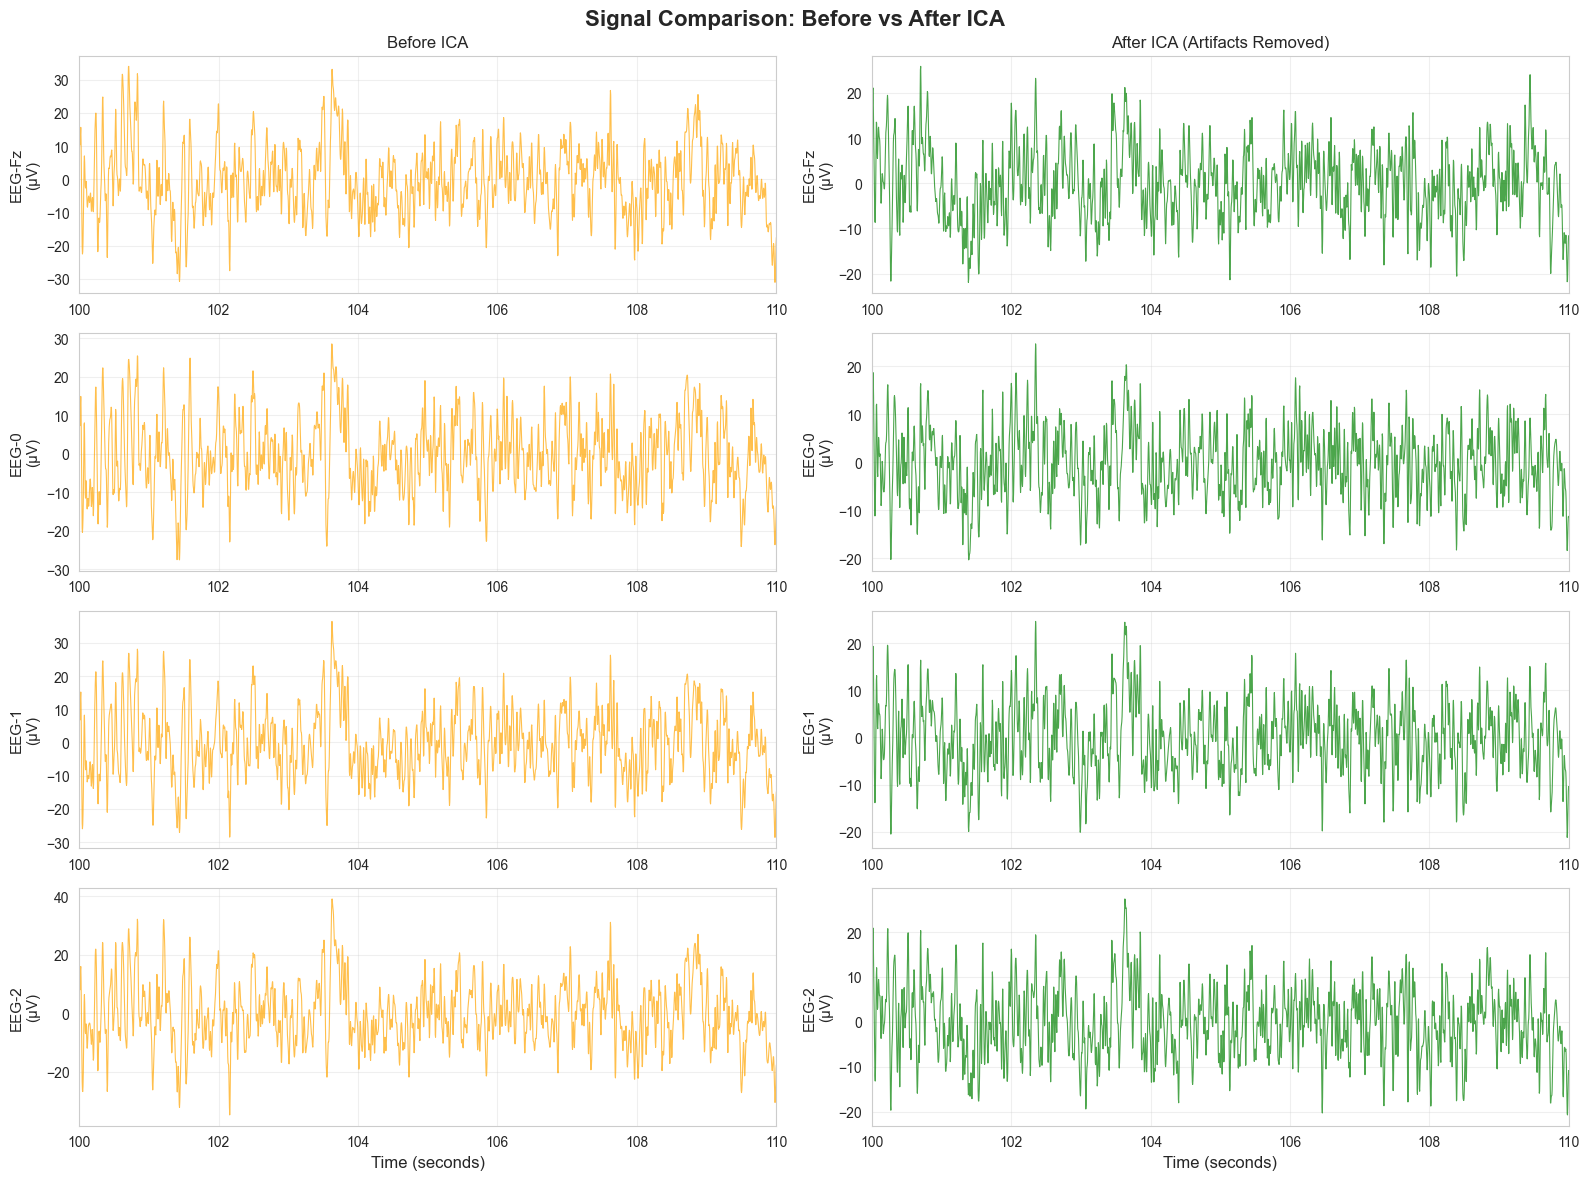

Notice: Eye blinks and large-amplitude artifacts are reduced after ICA.


In [55]:
# Plot comparison
fig, axes = plt.subplots(4, 2, figsize=(16, 12))
fig.suptitle('Signal Comparison: Before vs After ICA', fontsize=16, fontweight='bold')

# Find frontal channels
available_channels = raw_filtered.ch_names
channels_to_plot = []
for target in ['Fp1', 'Fp2', 'C3', 'C4']:
    for ch in available_channels:
        if target in ch:
            channels_to_plot.append(ch)
            break

# If we couldn't find enough, just use first 4 EEG channels
if len(channels_to_plot) < 4:
    channels_to_plot = [ch for ch in available_channels if 'EEG' in ch][:4]

time_window = [100, 110]  # 10-second window

for idx, ch_name in enumerate(channels_to_plot):
    ch_idx = raw_filtered.ch_names.index(ch_name)
    
    # Get data before ICA
    data_before, times = raw_filtered[ch_idx, :]
    time_mask = (times >= time_window[0]) & (times <= time_window[1])
    
    # Get data after ICA
    data_after, _ = raw_ica[ch_idx, :]
    
    # Plot before ICA
    axes[idx, 0].plot(times[time_mask], data_before[0, time_mask] * 1e6, 
                     linewidth=0.8, color='orange', alpha=0.7)
    axes[idx, 0].set_ylabel(f'{ch_name}\n(µV)', fontsize=11)
    axes[idx, 0].set_title('Before ICA' if idx == 0 else '', fontsize=12)
    axes[idx, 0].grid(True, alpha=0.3)
    axes[idx, 0].set_xlim(time_window)
    
    # Plot after ICA
    axes[idx, 1].plot(times[time_mask], data_after[0, time_mask] * 1e6, 
                     linewidth=0.8, color='green', alpha=0.7)
    axes[idx, 1].set_ylabel(f'{ch_name}\n(µV)', fontsize=11)
    axes[idx, 1].set_title('After ICA (Artifacts Removed)' if idx == 0 else '', fontsize=12)
    axes[idx, 1].grid(True, alpha=0.3)
    axes[idx, 1].set_xlim(time_window)

axes[-1, 0].set_xlabel('Time (seconds)', fontsize=12)
axes[-1, 1].set_xlabel('Time (seconds)', fontsize=12)
plt.tight_layout()
plt.show()

print("Notice: Eye blinks and large-amplitude artifacts are reduced after ICA.")

## Part 4: Epoch Extraction

**Step 3:** Extract fixed-length epochs around motor imagery cues

In [56]:
# Get events (motor imagery cues)
events, event_id = mne.events_from_annotations(raw_ica, verbose=False)

print(f"All event IDs found: {event_id}")

# Filter for motor imagery events
# BCI IV-2a motor imagery: 4 classes (left/right hand, feet, tongue)
# Event codes can be 769-772 or their annotation indices (7-10)

# Try to find the motor imagery events
mi_event_ids = {}

# Strategy 1: Look for 769-772 (standard BCI IV-2a codes)
for code in [769, 770, 771, 772]:
    if code in event_id.values():
        mi_event_ids.update({k: code for k, v in event_id.items() if v == code})

# Strategy 2: If not found, look for annotation indices 7-10
if len(mi_event_ids) == 0:
    for code in [7, 8, 9, 10]:
        if code in event_id.values():
            mi_event_ids.update({k: code for k, v in event_id.items() if v == code})

# Strategy 3: Look for any 4 consecutive event codes with high counts
if len(mi_event_ids) == 0:
    event_counts = [(k, v, (events[:, 2] == v).sum()) for k, v in event_id.items()]
    event_counts.sort(key=lambda x: x[2], reverse=True)
    mi_event_ids = {k: v for k, v, count in event_counts[:4] if count > 50}

print(f"Motor imagery event IDs found: {mi_event_ids}")
print(f"Total motor imagery events: {sum([np.sum(events[:, 2] == v) for v in mi_event_ids.values()])}")

All event IDs found: {np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
Motor imagery event IDs found: {np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
Total motor imagery events: 288


In [57]:
# Create epochs (0.5 sec before to 3.5 sec after cue)
tmin, tmax = 0.5, 3.5

print(f"Creating epochs: {tmin} to {tmax} seconds relative to cue...")

epochs = mne.Epochs(
    raw_ica,
    events,
    event_id=mi_event_ids,
    tmin=tmin,
    tmax=tmax,
    baseline=None,  # No baseline correction yet
    preload=True,
    verbose=False
)

print(f"\nEpochs created:")
print(f"  Number of epochs: {len(epochs)}")
print(f"  Epoch duration: {tmax - tmin} seconds")
print(f"  Sampling rate: {epochs.info['sfreq']} Hz")
print(f"  Number of samples per epoch: {epochs.get_data().shape[2]}")
print(f"  Epoch shape: {epochs.get_data().shape} (epochs × channels × samples)")

Creating epochs: 0.5 to 3.5 seconds relative to cue...

Epochs created:
  Number of epochs: 288
  Epoch duration: 3.0 seconds
  Sampling rate: 250.0 Hz
  Number of samples per epoch: 751
  Epoch shape: (288, 22, 751) (epochs × channels × samples)


### Visualize Epoched Data

Plotting epoch analysis for channel: EEG-C3
Event IDs to plot: {np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}


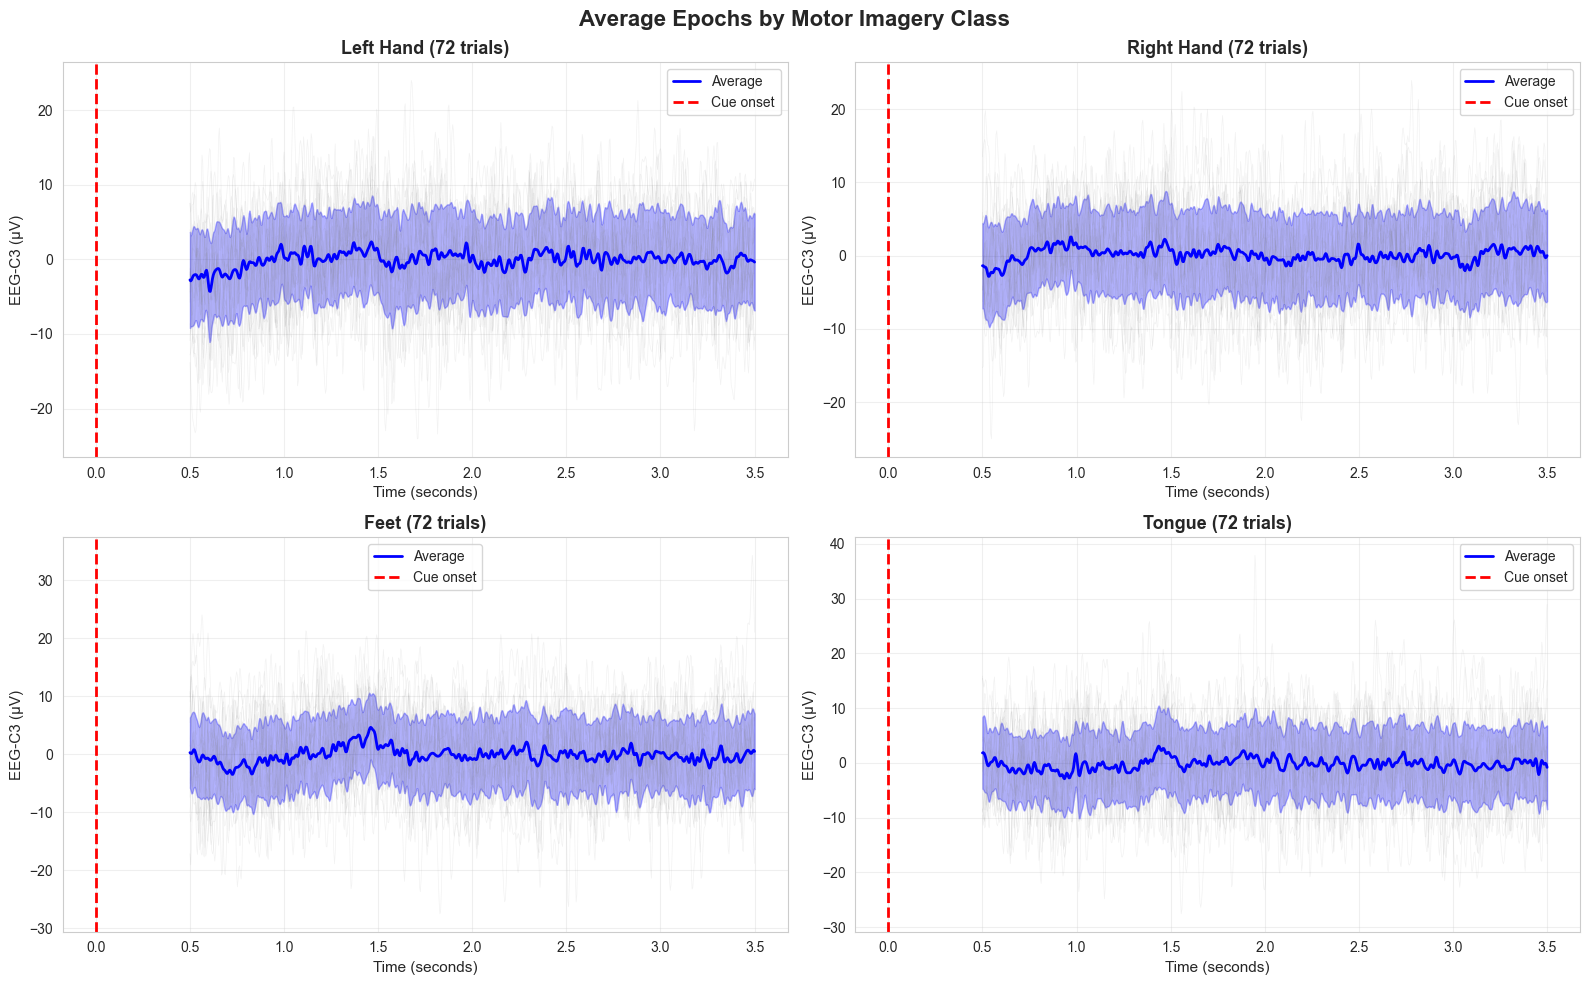

Notice: Each class shows different average EEG patterns over the motor cortex.


In [58]:
# Plot average epoch for each class
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Average Epochs by Motor Imagery Class', fontsize=16, fontweight='bold')

# Map event codes to class names
# Standard BCI IV-2a: 769=left, 770=right, 771=feet, 772=tongue
# Annotation indices: 7=left, 8=right, 9=feet, 10=tongue
class_mapping = {
    769: 'Left Hand',
    770: 'Right Hand', 
    771: 'Feet',
    772: 'Tongue',
    # Also handle annotation indices
    7: 'Left Hand',
    8: 'Right Hand',
    9: 'Feet',
    10: 'Tongue'
}

# Find a good channel for analysis
available_channels = epochs.ch_names
channel_to_plot = None
for target in ['C3', 'Cz', 'C4']:
    for ch in available_channels:
        if target in ch:
            channel_to_plot = ch
            break
    if channel_to_plot:
        break

if channel_to_plot is None:
    channel_to_plot = [ch for ch in available_channels if 'EEG' in ch][0]

print(f"Plotting epoch analysis for channel: {channel_to_plot}")
print(f"Event IDs to plot: {mi_event_ids}")

# Plot each event code found
plot_idx = 0
for event_key, event_code in mi_event_ids.items():
    if event_code in mi_event_ids.values():
        # Get epochs for this event code
        event_mask = epochs.events[:, 2] == event_code
        class_epochs = epochs[event_mask]
        
        if len(class_epochs) > 0:
            # Get data for selected channel
            if channel_to_plot in epochs.ch_names:
                ch_idx = epochs.ch_names.index(channel_to_plot)
                data = class_epochs.get_data()[:, ch_idx, :] * 1e6  # Convert to µV
                
                # Plot
                ax = axes[plot_idx // 2, plot_idx % 2]
                
                # Plot individual trials (light)
                for trial in data[:min(20, len(data))]:
                    ax.plot(epochs.times, trial, alpha=0.1, color='gray', linewidth=0.5)
                
                # Plot average (bold)
                ax.plot(epochs.times, data.mean(axis=0), linewidth=2, color='blue', label='Average')
                
                # Add standard deviation
                std = data.std(axis=0)
                mean = data.mean(axis=0)
                ax.fill_between(epochs.times, mean - std, mean + std, alpha=0.3, color='blue')
                
                ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Cue onset')
                
                # Get class name
                class_name = class_mapping.get(event_code, f'Event {event_code}')
                ax.set_title(f'{class_name} ({len(class_epochs)} trials)', fontsize=13, fontweight='bold')
                ax.set_xlabel('Time (seconds)', fontsize=11)
                ax.set_ylabel(f'{channel_to_plot} (µV)', fontsize=11)
                ax.grid(True, alpha=0.3)
                ax.legend()
                
                plot_idx += 1

# Hide unused subplots if fewer than 4 event types
for idx in range(plot_idx, 4):
    axes[idx // 2, idx % 2].axis('off')

plt.tight_layout()
plt.show()

print("Notice: Each class shows different average EEG patterns over the motor cortex.")

## Part 5: Artifact Rejection

**Step 4:** Remove epochs with extreme amplitudes (> 100 µV)

Analyzing epoch quality...
Total epochs before rejection: 288


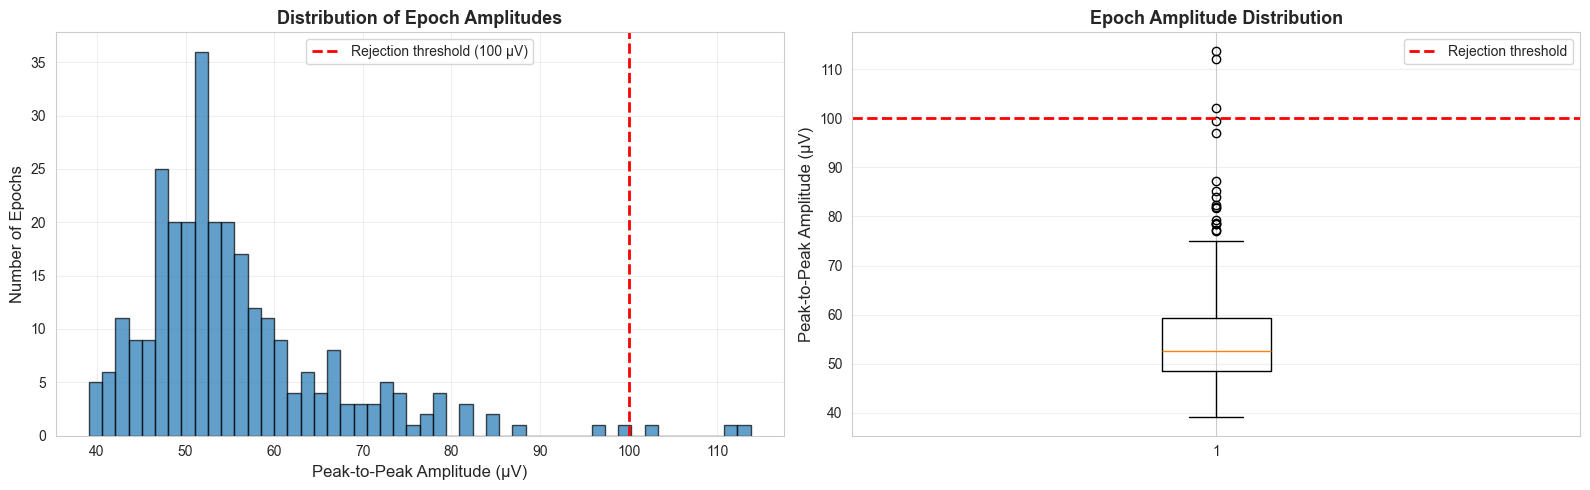


Rejection Statistics:
  Threshold: 100 µV
  Bad epochs: 3 / 288 (1.04%)
  Good epochs: 285 (98.96%)


In [59]:
# Check for bad epochs before rejection
print("Analyzing epoch quality...")
print(f"Total epochs before rejection: {len(epochs)}")

# Get data
epoch_data = epochs.get_data() * 1e6  # Convert to µV

# Calculate peak-to-peak amplitude per epoch
peak_to_peak = epoch_data.max(axis=(1, 2)) - epoch_data.min(axis=(1, 2))

# Plot histogram of amplitudes
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
axes[0].hist(peak_to_peak, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(100, color='red', linestyle='--', linewidth=2, label='Rejection threshold (100 µV)')
axes[0].set_xlabel('Peak-to-Peak Amplitude (µV)', fontsize=12)
axes[0].set_ylabel('Number of Epochs', fontsize=12)
axes[0].set_title('Distribution of Epoch Amplitudes', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(peak_to_peak, vert=True)
axes[1].axhline(100, color='red', linestyle='--', linewidth=2, label='Rejection threshold')
axes[1].set_ylabel('Peak-to-Peak Amplitude (µV)', fontsize=12)
axes[1].set_title('Epoch Amplitude Distribution', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Identify bad epochs
reject_threshold = 100  # µV
bad_epochs = peak_to_peak > reject_threshold
rejection_rate = (bad_epochs.sum() / len(epochs)) * 100

print(f"\nRejection Statistics:")
print(f"  Threshold: {reject_threshold} µV")
print(f"  Bad epochs: {bad_epochs.sum()} / {len(epochs)} ({rejection_rate:.2f}%)")
print(f"  Good epochs: {(~bad_epochs).sum()} ({100-rejection_rate:.2f}%)")

In [60]:
# Apply rejection
epochs_clean = epochs.copy()

# Drop bad epochs
if bad_epochs.sum() > 0:
    epochs_clean.drop(np.where(bad_epochs)[0], reason='Amplitude', verbose=False)
    print(f"Dropped {bad_epochs.sum()} epochs with excessive amplitude.")
else:
    print("No epochs rejected (all below threshold).")

print(f"\nRemaining epochs: {len(epochs_clean)}")

Dropped 3 epochs with excessive amplitude.

Remaining epochs: 285


## Part 6: Z-Score Normalization

**Step 5:** Normalize each channel to have zero mean and unit variance

In [61]:
# Get clean epoch data
data_before_norm = epochs_clean.get_data() * 1e6  # Convert to µV

print("Applying Z-score normalization...")
print(f"Input shape: {data_before_norm.shape} (epochs × channels × samples)")

# Apply z-score normalization per channel per epoch
data_normalized = np.zeros_like(data_before_norm)
for epoch_idx in range(data_before_norm.shape[0]):
    for ch_idx in range(data_before_norm.shape[1]):
        signal = data_before_norm[epoch_idx, ch_idx, :]
        mean = signal.mean()
        std = signal.std()
        if std > 0:
            data_normalized[epoch_idx, ch_idx, :] = (signal - mean) / std
        else:
            data_normalized[epoch_idx, ch_idx, :] = signal - mean

print(f"Output shape: {data_normalized.shape}")
print(f"\nNormalization verification:")
print(f"  Mean (should be ~0): {data_normalized.mean():.6f}")
print(f"  Std (should be ~1): {data_normalized.std():.6f}")

Applying Z-score normalization...
Input shape: (285, 22, 751) (epochs × channels × samples)
Output shape: (285, 22, 751)

Normalization verification:
  Mean (should be ~0): -0.000000
  Std (should be ~1): 1.000000


### Compare: Before vs After Normalization

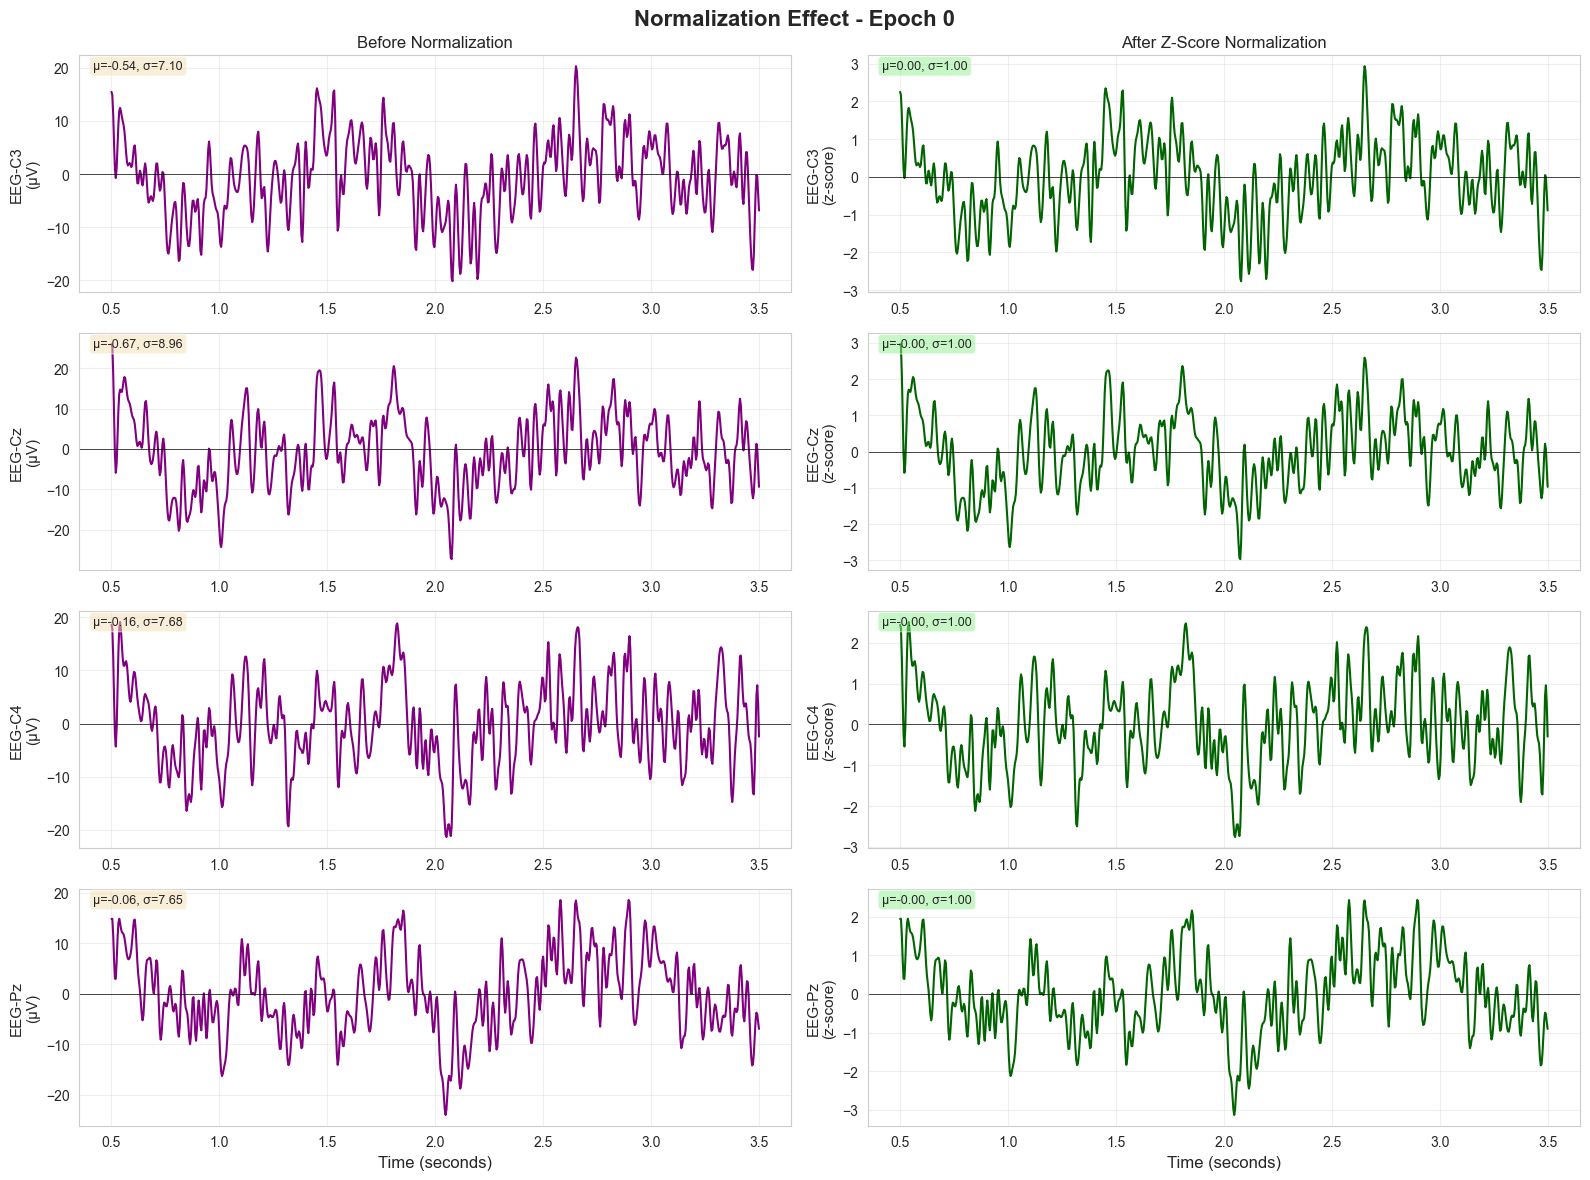

Notice: After normalization, all channels have mean ≈ 0 and std ≈ 1


In [62]:
# Plot comparison for one epoch
epoch_idx = 0

# Find good channels for visualization
available_channels = epochs_clean.ch_names
channels_to_plot = []
for target in ['C3', 'Cz', 'C4', 'Pz']:
    for ch in available_channels:
        if target in ch:
            channels_to_plot.append(ch)
            break

# If we couldn't find enough, just use first 4 EEG channels
if len(channels_to_plot) < 4:
    channels_to_plot = [ch for ch in available_channels if 'EEG' in ch][:4]

fig, axes = plt.subplots(4, 2, figsize=(16, 12))
fig.suptitle(f'Normalization Effect - Epoch {epoch_idx}', fontsize=16, fontweight='bold')

for idx, ch_name in enumerate(channels_to_plot):
    if ch_name in epochs_clean.ch_names:
        ch_idx = epochs_clean.ch_names.index(ch_name)
        
        # Before normalization
        axes[idx, 0].plot(epochs_clean.times, data_before_norm[epoch_idx, ch_idx, :], 
                         linewidth=1.5, color='purple')
        axes[idx, 0].set_ylabel(f'{ch_name}\n(µV)', fontsize=11)
        axes[idx, 0].set_title('Before Normalization' if idx == 0 else '', fontsize=12)
        axes[idx, 0].grid(True, alpha=0.3)
        axes[idx, 0].axhline(0, color='black', linestyle='-', linewidth=0.5)
        
        # After normalization
        axes[idx, 1].plot(epochs_clean.times, data_normalized[epoch_idx, ch_idx, :], 
                         linewidth=1.5, color='darkgreen')
        axes[idx, 1].set_ylabel(f'{ch_name}\n(z-score)', fontsize=11)
        axes[idx, 1].set_title('After Z-Score Normalization' if idx == 0 else '', fontsize=12)
        axes[idx, 1].grid(True, alpha=0.3)
        axes[idx, 1].axhline(0, color='black', linestyle='-', linewidth=0.5)
        
        # Add statistics
        before_mean = data_before_norm[epoch_idx, ch_idx, :].mean()
        before_std = data_before_norm[epoch_idx, ch_idx, :].std()
        after_mean = data_normalized[epoch_idx, ch_idx, :].mean()
        after_std = data_normalized[epoch_idx, ch_idx, :].std()
        
        axes[idx, 0].text(0.02, 0.98, f'μ={before_mean:.2f}, σ={before_std:.2f}',
                         transform=axes[idx, 0].transAxes, fontsize=9,
                         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        axes[idx, 1].text(0.02, 0.98, f'μ={after_mean:.2f}, σ={after_std:.2f}',
                         transform=axes[idx, 1].transAxes, fontsize=9,
                         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

axes[-1, 0].set_xlabel('Time (seconds)', fontsize=12)
axes[-1, 1].set_xlabel('Time (seconds)', fontsize=12)
plt.tight_layout()
plt.show()

print("Notice: After normalization, all channels have mean ≈ 0 and std ≈ 1")

## Part 7: Final Preprocessed Data Summary

In [63]:
# Get event labels
labels = epochs_clean.events[:, 2]

# Map to class labels (0-3)
unique_events = np.unique(labels)
label_mapping = {event: idx for idx, event in enumerate(sorted(unique_events))}
class_labels = np.array([label_mapping[label] for label in labels])

print("="*80)
print("FINAL PREPROCESSED DATA SUMMARY")
print("="*80)
print(f"\nData Shape: {data_normalized.shape}")
print(f"  - Epochs: {data_normalized.shape[0]}")
print(f"  - Channels: {data_normalized.shape[1]}")
print(f"  - Samples per epoch: {data_normalized.shape[2]}")
print(f"  - Duration per epoch: {epochs_clean.times[-1] - epochs_clean.times[0]:.2f} seconds")
print(f"  - Sampling rate: {epochs_clean.info['sfreq']} Hz")

print(f"\nClass Distribution:")
for class_idx in range(4):
    count = (class_labels == class_idx).sum()
    percentage = (count / len(class_labels)) * 100
    class_name = list(class_mapping.values())[class_idx]
    print(f"  Class {class_idx} ({class_name}): {count} epochs ({percentage:.1f}%)")

print(f"\nData Quality Metrics:")
print(f"  - Mean: {data_normalized.mean():.6f} (target: 0)")
print(f"  - Std: {data_normalized.std():.6f} (target: 1)")
print(f"  - Min: {data_normalized.min():.2f}")
print(f"  - Max: {data_normalized.max():.2f}")

print(f"\nPreprocessing Steps Applied:")
print(f"  [x] Band-pass filter (0.5-40 Hz)")
print(f"  [x] Notch filter (50 Hz)")
print(f"  [x] ICA artifact removal ({len(ica.exclude)} components)")
print(f"  [x] Epoch extraction (0.5 to 3.5 seconds)")
print(f"  [x] Artifact rejection ({bad_epochs.sum()} epochs removed)")
print(f"  [x] Z-score normalization")

print(f"\nData is ready for Phase 3: Image Transformation")
print("="*80)

FINAL PREPROCESSED DATA SUMMARY

Data Shape: (285, 22, 751)
  - Epochs: 285
  - Channels: 22
  - Samples per epoch: 751
  - Duration per epoch: 3.00 seconds
  - Sampling rate: 250.0 Hz

Class Distribution:
  Class 0 (Left Hand): 70 epochs (24.6%)
  Class 1 (Right Hand): 72 epochs (25.3%)
  Class 2 (Feet): 72 epochs (25.3%)
  Class 3 (Tongue): 71 epochs (24.9%)

Data Quality Metrics:
  - Mean: -0.000000 (target: 0)
  - Std: 1.000000 (target: 1)
  - Min: -5.14
  - Max: 5.33

Preprocessing Steps Applied:
  [x] Band-pass filter (0.5-40 Hz)
  [x] Notch filter (50 Hz)
  [x] ICA artifact removal (2 components)
  [x] Epoch extraction (0.5 to 3.5 seconds)
  [x] Artifact rejection (3 epochs removed)
  [x] Z-score normalization

Data is ready for Phase 3: Image Transformation


### Visualize Final Preprocessed Data

In [ ]:
# Create comprehensive visualization of final data
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Class distribution pie chart
ax1 = fig.add_subplot(gs[0, 0])
class_counts = [np.sum(class_labels == i) for i in range(4)]
# Get only the relevant class names from the actual events found (not all 8 possible mappings)
relevant_labels = [class_mapping[code] for code in sorted(mi_event_ids.values())]
ax1.pie(class_counts, labels=relevant_labels, autopct='%1.1f%%', startangle=90)
ax1.set_title('Class Distribution', fontsize=13, fontweight='bold')

# 2. Data shape visualization
ax2 = fig.add_subplot(gs[0, 1])
ax2.text(0.5, 0.7, f'Data Shape:\n{data_normalized.shape}', 
         ha='center', va='center', fontsize=16, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
ax2.text(0.5, 0.3, f'{data_normalized.shape[0]} epochs\n{data_normalized.shape[1]} channels\n{data_normalized.shape[2]} samples', 
         ha='center', va='center', fontsize=12)
ax2.axis('off')
ax2.set_title('Data Dimensions', fontsize=13, fontweight='bold')

# 3. Normalization distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(data_normalized.flatten()[::100], bins=100, edgecolor='black', alpha=0.7)
ax3.axvline(0, color='red', linestyle='--', linewidth=2, label='Mean')
ax3.set_xlabel('Z-Score Value', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Normalized Data Distribution', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Find a good channel for epoch plots
available_channels = epochs_clean.ch_names
channel_idx = None
for target in ['C3', 'Cz', 'C4']:
    for ch_idx_temp, ch in enumerate(available_channels):
        if target in ch:
            channel_idx = ch_idx_temp
            break
    if channel_idx:
        break

if channel_idx is None:
    channel_idx = 0

# 4-7. Sample epochs for each class
for class_idx in range(4):
    ax = fig.add_subplot(gs[1 + class_idx // 2, class_idx % 2])
    
    # Get epochs for this class
    class_epoch_indices = np.where(class_labels == class_idx)[0]
    if len(class_epoch_indices) > 0:
        # Plot a few sample epochs
        for i in range(min(5, len(class_epoch_indices))):
            epoch_idx = class_epoch_indices[i]
            ax.plot(epochs_clean.times, data_normalized[epoch_idx, channel_idx, :], 
                   alpha=0.3, linewidth=0.8)
        
        # Plot average
        avg = data_normalized[class_epoch_indices, channel_idx, :].mean(axis=0)
        ax.plot(epochs_clean.times, avg, linewidth=2, color='red', label='Average')
        
        ax.set_title(f'Class {class_idx}: {list(class_mapping.values())[class_idx]}', 
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('Time (s)', fontsize=10)
        ax.set_ylabel('Amplitude (z-score)', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        ax.axvline(0, color='green', linestyle='--', linewidth=1, alpha=0.5)

# 8. Channel correlation heatmap (sample epoch)
ax8 = fig.add_subplot(gs[2, 2])
sample_epoch_data = data_normalized[0, :, :]  # First epoch
corr_matrix = np.corrcoef(sample_epoch_data)
im = ax8.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax8.set_title('Channel Correlation\n(Sample Epoch)', fontsize=12, fontweight='bold')
ax8.set_xlabel('Channel Index', fontsize=10)
ax8.set_ylabel('Channel Index', fontsize=10)
plt.colorbar(im, ax=ax8, fraction=0.046, pad=0.04)

fig.suptitle('Phase 2 Preprocessing: Final Data Quality Summary', fontsize=18, fontweight='bold', y=0.98)
plt.show()

print("Complete visualization generated.")

## Part 8: Comparison with Combined Dataset

Let's verify this matches what we have in the combined HDF5 file:

In [ ]:
# Load the combined preprocessed data
combined_file = Path('data/BCI_IV_2a.hdf5')

if combined_file.exists():
    print(f"Loading combined dataset: {combined_file}")
    
    with h5py.File(combined_file, 'r') as f:
        # Load subject A01T
        subject_key = 'subject_A01T'
        signals = f[f'{subject_key}/signals'][:]
        labels_stored = f[f'{subject_key}/labels'][:]
        
        print(f"\nCombined dataset - Subject A01T:")
        print(f"  Shape: {signals.shape}")
        print(f"  Number of trials: {signals.shape[0]}")
        print(f"  Channels: {signals.shape[1]}")
        print(f"  Samples: {signals.shape[2]}")
        print(f"\n  Mean: {signals.mean():.6f}")
        print(f"  Std: {signals.std():.6f}")
        print(f"  Min: {signals.min():.2f}")
        print(f"  Max: {signals.max():.2f}")
        
        print(f"\nClass distribution in stored data:")
        for class_idx in range(4):
            count = (labels_stored == class_idx).sum()
            percentage = (count / len(labels_stored)) * 100
            print(f"  Class {class_idx}: {count} epochs ({percentage:.1f}%)")
else:
    print(f"Combined dataset not found at {combined_file}")
    print("Run: python experiments/scripts/combine_preprocessed_data.py")

## Summary

### Phase 2 Preprocessing Pipeline Complete

This notebook demonstrated the complete preprocessing pipeline:

1. **Raw Data Loading** - Loaded unprocessed GDF files
2. **Frequency Filtering** - Applied band-pass (0.5-40 Hz) and notch (50 Hz) filters
3. **ICA Artifact Removal** - Removed eye blinks and muscle artifacts
4. **Epoch Extraction** - Created fixed-length trials around motor imagery cues
5. **Artifact Rejection** - Removed epochs with excessive amplitude
6. **Z-Score Normalization** - Standardized data for neural network training

### Key Results:

- **High-quality preprocessed data** ready for image transformation
- **Balanced classes** (~25% each of 4 motor imagery tasks)
- **Standardized format** (mean ≈ 0, std ≈ 1)
- **Artifact-free signals** suitable for deep learning

### Next Step: Phase 3

The preprocessed data will be transformed into 6 different image representations:
- GAF (Gramian Angular Fields)
- MTF (Markov Transition Fields)
- RP (Recurrence Plots)
- STFT (Spectrograms)
- CWT (Scalograms)
- Topographic Maps

These images will then be used to train CNN and Vision Transformer models.